                                                                Task 3                                                                           

                                                          Sales Predictions                                                                     

      SALES PREDICTION - ADVERTISING DATASET

Dataset Shape  : (200, 4)
Columns        : ['TV', 'Radio', 'Newspaper', 'Sales']

First 5 Rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Dataset Statistics:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000

[STEP 2] Checking Data Quality...
Missing Values :
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

✅ No missing values —

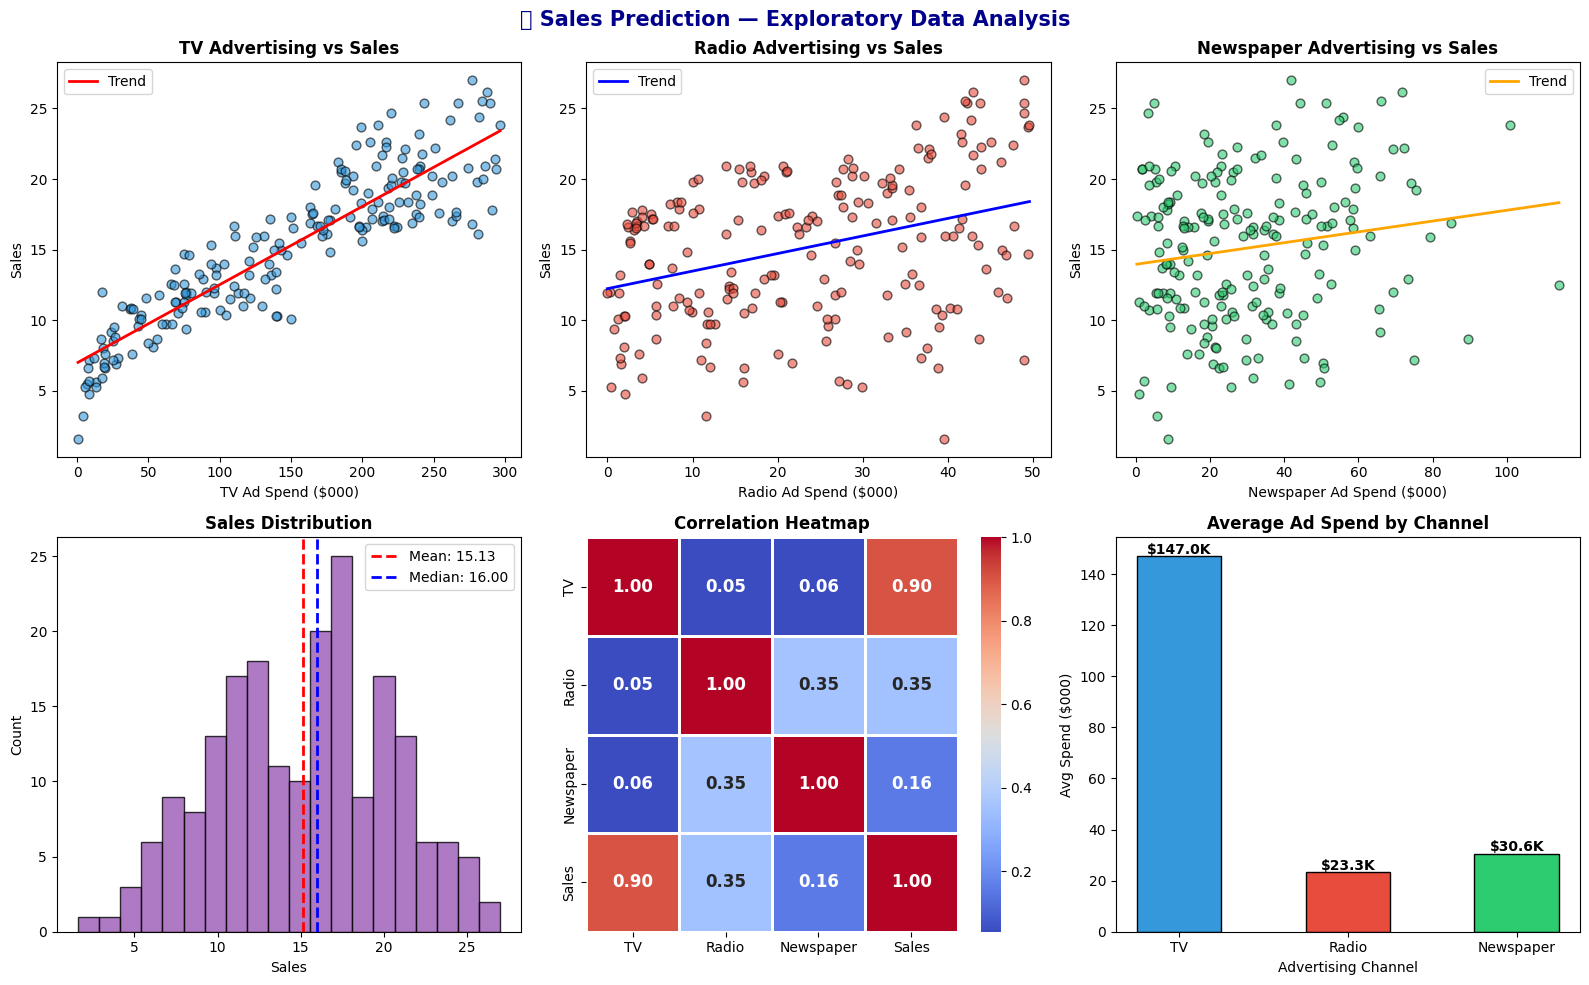

✅ EDA chart saved → eda_sales.png

[STEP 4] Preparing Data...
Train samples  : 160
Test samples   : 40

[STEP 5] Training Models...

-------------------------------------------------------

📌 Linear Regression
   MAE            : 1.2748
   RMSE           : 1.7052
   R² Score       : 0.9059
   CV R² (5-fold) : 0.8954

📌 Random Forest
   MAE            : 0.9180
   RMSE           : 1.1989
   R² Score       : 0.9535
   CV R² (5-fold) : 0.9417

📌 Gradient Boosting
   MAE            : 0.8301
   RMSE           : 1.1204
   R² Score       : 0.9594
   CV R² (5-fold) : 0.9386

[STEP 6] Generating Result Charts...


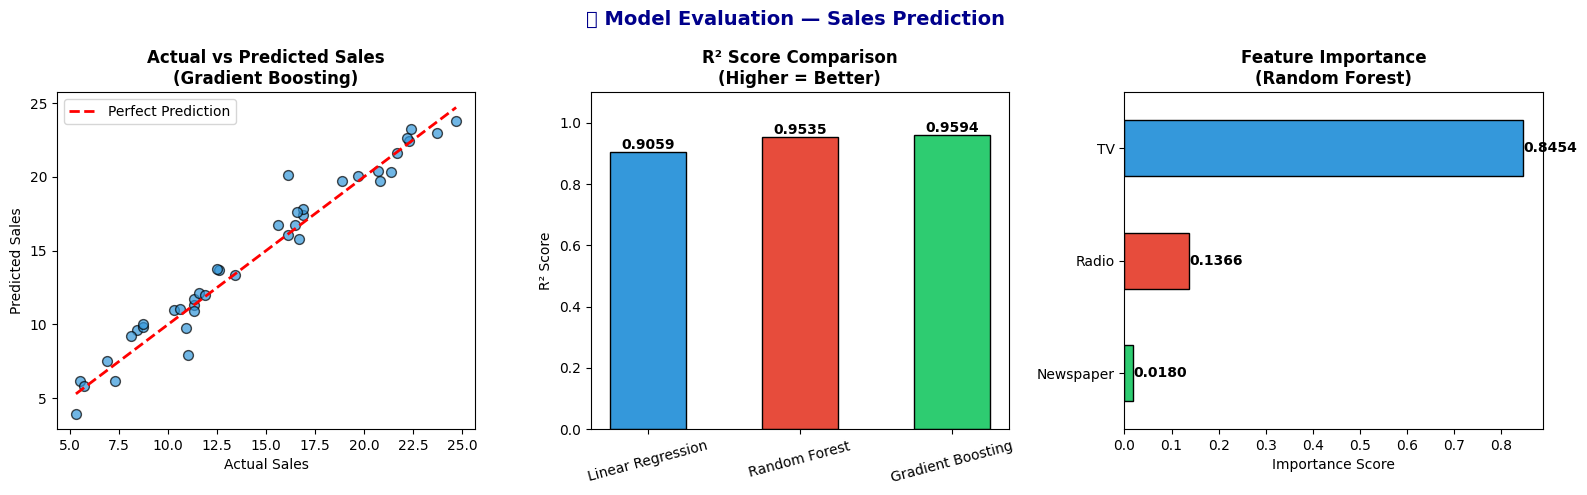

✅ Model results chart saved → model_results_sales.png

[STEP 7] Predicting Sales for New Ad Budgets...

📦 Prediction Results:
--------------------------------------------------
    TV   Radio  Newspaper  Predicted Sales
--------------------------------------------------
   200      40         30            20.28
   150      20         15            13.83
    50      10          5            10.02
   100      30         20            14.23

               FINAL SUMMARY

Model                      MAE    RMSE      R²   CV R²
-------------------------------------------------------
Linear Regression       1.2748  1.7052  0.9059  0.8954
Random Forest           0.9180  1.1989  0.9535  0.9417
Gradient Boosting       0.8301  1.1204  0.9594  0.9386  ✅ BEST

🏆 Best Model  : Gradient Boosting
   R² Score    : 0.9594
   MAE         : 0.8301

💡 Key Insight : TV ads have the strongest impact on Sales!

📁 Output Files:
   → eda_sales.png
   → model_results_sales.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD DATASET 
df = pd.read_csv(r"C:\Data Set (Practice)\advertising.csv")

print("=" * 55)
print("      SALES PREDICTION - ADVERTISING DATASET")
print("=" * 55)
print(f"\nDataset Shape  : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")
print(f"\nFirst 5 Rows:")
print(df.head())
print(f"\nDataset Statistics:")
print(df.describe())

# 2. DATA CHECKING
print("\n[STEP 2] Checking Data Quality...")
print(f"Missing Values :\n{df.isnull().sum()}")
print(f"\n✅ No missing values — dataset is clean!")

# 3. EDA VISUALIZATION
print("\n[STEP 3] Generating EDA Charts...")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("📊 Sales Prediction — Exploratory Data Analysis",
            fontsize=15, fontweight='bold', color='darkblue')

# 1 — TV vs Sales
axes[0,0].scatter(df['TV'], df['Sales'],
                color='#3498db', alpha=0.6, edgecolors='black', s=40)
z = np.polyfit(df['TV'], df['Sales'], 1)
p = np.poly1d(z)
axes[0,0].plot(sorted(df['TV']), p(sorted(df['TV'])),
            color='red', linewidth=2, label='Trend')
axes[0,0].set_title("TV Advertising vs Sales", fontweight='bold')
axes[0,0].set_xlabel("TV Ad Spend ($000)")
axes[0,0].set_ylabel("Sales")
axes[0,0].legend()

# 2 — Radio vs Sales
axes[0,1].scatter(df['Radio'], df['Sales'],
                color='#e74c3c', alpha=0.6, edgecolors='black', s=40)
z2 = np.polyfit(df['Radio'], df['Sales'], 1)
p2 = np.poly1d(z2)
axes[0,1].plot(sorted(df['Radio']), p2(sorted(df['Radio'])),
            color='blue', linewidth=2, label='Trend')
axes[0,1].set_title("Radio Advertising vs Sales", fontweight='bold')
axes[0,1].set_xlabel("Radio Ad Spend ($000)")
axes[0,1].set_ylabel("Sales")
axes[0,1].legend()

# 3 — Newspaper vs Sales
axes[0,2].scatter(df['Newspaper'], df['Sales'],
                color='#2ecc71', alpha=0.6, edgecolors='black', s=40)
z3 = np.polyfit(df['Newspaper'], df['Sales'], 1)
p3 = np.poly1d(z3)
axes[0,2].plot(sorted(df['Newspaper']), p3(sorted(df['Newspaper'])),
            color='orange', linewidth=2, label='Trend')
axes[0,2].set_title("Newspaper Advertising vs Sales", fontweight='bold')
axes[0,2].set_xlabel("Newspaper Ad Spend ($000)")
axes[0,2].set_ylabel("Sales")
axes[0,2].legend()

# 4 — Sales Distribution
axes[1,0].hist(df['Sales'], bins=20, color='#9b59b6',
            edgecolor='black', alpha=0.8)
axes[1,0].axvline(df['Sales'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {df['Sales'].mean():.2f}")
axes[1,0].axvline(df['Sales'].median(), color='blue', linestyle='--',
                linewidth=2, label=f"Median: {df['Sales'].median():.2f}")
axes[1,0].set_title("Sales Distribution", fontweight='bold')
axes[1,0].set_xlabel("Sales")
axes[1,0].set_ylabel("Count")
axes[1,0].legend()

# 5 — Correlation Heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1,1], linewidths=1,
            annot_kws={'size': 12, 'weight': 'bold'})
axes[1,1].set_title("Correlation Heatmap", fontweight='bold')

# 6 — Ad Spend Comparison (avg)
avg_spend = df[['TV', 'Radio', 'Newspaper']].mean()
colors    = ['#3498db', '#e74c3c', '#2ecc71']
bars = axes[1,2].bar(avg_spend.index, avg_spend.values,
                    color=colors, edgecolor='black', width=0.5)
axes[1,2].set_title("Average Ad Spend by Channel", fontweight='bold')
axes[1,2].set_xlabel("Advertising Channel")
axes[1,2].set_ylabel("Avg Spend ($000)")
for bar, val in zip(bars, avg_spend.values):
    axes[1,2].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f"${val:.1f}K", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("eda_sales.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✅ EDA chart saved → eda_sales.png")

# 4. PREPARE DATA 
print("\n[STEP 4] Preparing Data...")

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train samples  : {len(X_train)}")
print(f"Test samples   : {len(X_test)}")

# 5. TRAIN MODELS 
print("\n[STEP 5] Training Models...")

models = {
    "Linear Regression"  : LinearRegression(),
    "Random Forest"      : RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting"  : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
print("\n" + "-" * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds  = model.predict(X_test)
    mae    = mean_absolute_error(y_test, preds)
    rmse   = np.sqrt(mean_squared_error(y_test, preds))
    r2     = r2_score(y_test, preds)
    cv     = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV': cv, 'preds': preds}

    print(f"\n📌 {name}")
    print(f"   MAE            : {mae:.4f}")
    print(f"   RMSE           : {rmse:.4f}")
    print(f"   R² Score       : {r2:.4f}")
    print(f"   CV R² (5-fold) : {cv:.4f}")

# 6. RESULT CHARTS   
print("\n[STEP 6] Generating Result Charts...")

best_name  = max(results, key=lambda x: results[x]['R2'])
best_preds = results[best_name]['preds']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("📈 Model Evaluation — Sales Prediction",
            fontsize=14, fontweight='bold', color='darkblue')

# 1 — Actual vs Predicted
axes[0].scatter(y_test, best_preds, color='#3498db',
                alpha=0.7, edgecolors='black', s=50)
axes[0].plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f"Actual vs Predicted Sales\n({best_name})", fontweight='bold')
axes[0].set_xlabel("Actual Sales")
axes[0].set_ylabel("Predicted Sales")
axes[0].legend()

# 2 — R² Score Comparison
names  = list(results.keys())
r2s    = [results[m]['R2'] for m in names]
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars   = axes[1].bar(names, r2s, color=colors, edgecolor='black', width=0.5)
axes[1].set_title("R² Score Comparison\n(Higher = Better)", fontweight='bold')
axes[1].set_ylabel("R² Score")
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{val:.4f}", ha='center', fontweight='bold')

# 3 — Feature Importance (Random Forest)
rf       = models["Random Forest"]
feat_imp = pd.Series(rf.feature_importances_,
                    index=['TV', 'Radio', 'Newspaper']).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[2],
            color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black')
axes[2].set_title("Feature Importance\n(Random Forest)", fontweight='bold')
axes[2].set_xlabel("Importance Score")
for i, val in enumerate(feat_imp.values):
    axes[2].text(val + 0.002, i, f"{val:.4f}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("model_results_sales.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✅ Model results chart saved → model_results_sales.png")

# 7. PREDICT NEW VALUES 
print("\n[STEP 7] Predicting Sales for New Ad Budgets...")

best_model = models[best_name]
new_data   = pd.DataFrame({
    'TV'       : [200, 150, 50,  100],
    'Radio'    : [40,  20,  10,  30],
    'Newspaper': [30,  15,  5,   20]
})

new_preds = best_model.predict(new_data)
print("\n📦 Prediction Results:")
print("-" * 50)
print(f"{'TV':>6} {'Radio':>7} {'Newspaper':>10} {'Predicted Sales':>16}")
print("-" * 50)
for i, row in new_data.iterrows():
    print(f"{row['TV']:>6} {row['Radio']:>7} {row['Newspaper']:>10} {new_preds[i]:>16.2f}")

# 8. FINAL SUMMARY 
print("\n" + "=" * 55)
print("               FINAL SUMMARY")
print("=" * 55)
print(f"\n{'Model':<22} {'MAE':>7} {'RMSE':>7} {'R²':>7} {'CV R²':>7}")
print("-" * 55)
for name, m in results.items():
    tag = "  ✅ BEST" if name == best_name else ""
    print(f"{name:<22} {m['MAE']:>7.4f} {m['RMSE']:>7.4f} {m['R2']:>7.4f} {m['CV']:>7.4f}{tag}")

print(f"\n🏆 Best Model  : {best_name}")
print(f"   R² Score    : {results[best_name]['R2']:.4f}")
print(f"   MAE         : {results[best_name]['MAE']:.4f}")
print(f"\n💡 Key Insight : TV ads have the strongest impact on Sales!")
print("\n📁 Output Files:")
print("   → eda_sales.png")
print("   → model_results_sales.png")
print("=" * 55)